###First we tried the quadratic equation but upon no getting the desired output, we tried the cubic equation as well

for quad, the result with epoch value 50000 is not as great as is with cubic equation!

for 2nd order equation: 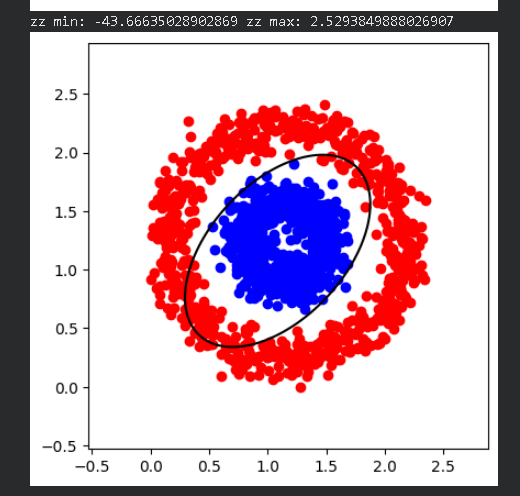

fir 3rd order equation: 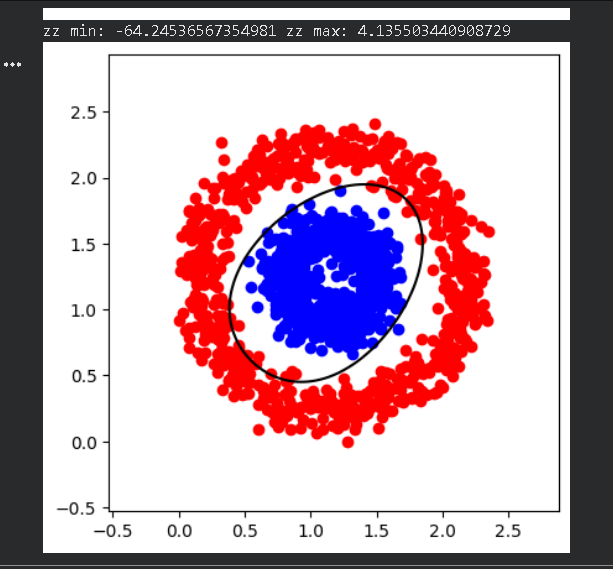

###But both get stuck on later epoches and gradually becomes stagnant

current problem is to find why the weights are not getting optimised further
after 20% epochs, the model is almost stagnant, even though the weights are not quite perfect, showing that the classical maths does not do a great job at gradient descent at this lvl




##Code which was used


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_blobs, make_circles

X, Y = make_circles(n_samples=(750, 750),shuffle=True, random_state=40, noise=0.1, factor=0.35 )
print(X.shape)
print(Y.shape)

x1_min = X[0][0]
x2_min = X[0][1]
for i in range(1,1500):
    if(X[i][0] < x1_min):
        x1_min = X[i][0]
    if(X[i][1] < x2_min):
        x2_min = X[i][1]


print(X)
print("-----------------------------------------------------")

X[:,0] -= x1_min
X[:,1] -= x2_min
print("-----------------------------------------------------")
print(X)



X = np.c_[np.ones(X.shape[0]) , X, (X[:,0]*X[:,0]) , (X[:,1]*X[:,1]) , (X[:,0]*X[:,1])]
print(X.shape)
X[0:5]

avgx = np.mean(X[:,2])
avgy = np.mean(X[:,1])
print(avgx," ", avgy," ")

plt.scatter(X[:, 2], X[:, 1], c=Y)
plt.title("make_circles")



#Output
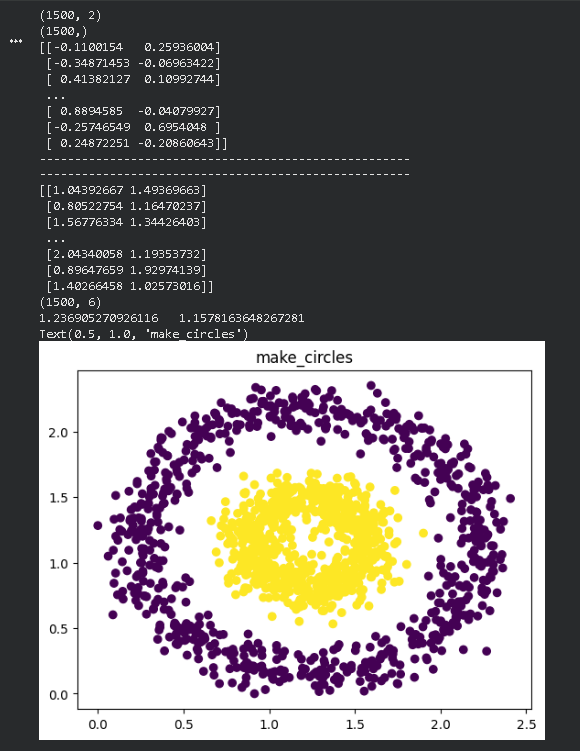

In [ ]:
class CircularLogisticRegression:

  def __init__(self):
    self.weights = np.array([0.5,0.5,0.5,0.5,0.5,0.5])
    self.lr = 0.01

  def sigmoid(self, y):
    return (1/(1+np.exp(-y)))

  def fit(self,X,Y):
    for epoch in range(50000):
      for j in range(len(X)):

          #i = np.random.randint(len(X))
          #i=j
          #ab = X[j]
          #a = ab[0]
          #b = ab[1]
          #a*a + b*b + self.f*a + self.g*b + ((self.f**2)/4 + (self.g**2)/4 - self.r**2)

          z = np.dot( X[j] , self.weights )
          y_pred = self.sigmoid(z)
          self.weights += self.lr*(Y[j] - y_pred) * X[j]/ X.shape[0]

          if (j == 1400) and (epoch%100==0):
            print(f"Epoch {epoch}")
            plot_decision_boundary(X, Y, self)




def plot_decision_boundary(X, Y, model):

    # Scatter original points
    plt.scatter(X[Y == 0, 1], X[Y == 0, 2], color='red')
    plt.scatter(X[Y == 1, 1], X[Y == 1, 2], color='blue')

    # Create grid
    x_vals = np.linspace(X[:,1].min()-0.53, X[:,1].max()+0.53, 200)
    y_vals = np.linspace(X[:,2].min()-0.53, X[:,2].max()+0.53, 200)
    xx, yy = np.meshgrid(x_vals, y_vals)

    # Compute model output on grid
    zz = (
        model.weights[0]
        + model.weights[1]*xx
        + model.weights[2]*yy
        + model.weights[3]*xx**2
        + model.weights[4]*yy**2
        + model.weights[5]*yy*xx
    )

    # Plot decision boundary
    print("zz min:", zz.min(), "zz max:", zz.max())
    plt.contour(xx, yy, zz, levels=[0], colors='black')

    plt.gca().set_aspect('equal')

    plt.show()


clr= CircularLogisticRegression()
clr.fit(X,Y)


plot_decision_boundary(X, Y, clr)